In [20]:
# Vérification GPU
import torch
print("GPU disponible :", torch.cuda.is_available())
print("Device :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


GPU disponible : True
Device : NVIDIA GeForce RTX 4060 Laptop GPU


In [21]:
# =============================================================================
# CELLULE 2 — Imports communs
# =============================================================================

import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import (
    CamembertTokenizer,
    CamembertModel,
    CamembertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Détection automatique GPU/CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device utilisé : cuda
GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM disponible : 8.6 GB


In [22]:
# =============================================================================
# CELLULE 2 — Chargement du fichier (local)
# =============================================================================

import os

# Mettre le chemin vers le fichier Excel (meme dossier que le notebook par defaut)
FILE_PATH = 'fr_EOHL_Reddit_prediction.xlsx'

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f'Fichier introuvable : {os.path.abspath(FILE_PATH)}')

print(f'Fichier trouve : {os.path.abspath(FILE_PATH)}')
print(f'Taille         : {os.path.getsize(FILE_PATH) / 1024:.1f} Ko')


Fichier trouve : c:\Users\pc\Desktop\Projet Meriem\fr_EOHL_Reddit_prediction.xlsx
Taille         : 3157.6 Ko


In [23]:
# =============================================================================
# CELLULE 3 — Chargement des données
# =============================================================================

df = pd.read_excel('fr_EOHL_Reddit_prediction.xlsx')

In [24]:
# =============================================================================
# CELLULE 4 — Imports & configuration
# =============================================================================
from collections import Counter

# Affichage inline dans Colab
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)

print("✅ Imports OK")

✅ Imports OK


In [25]:
# =============================================================================
# CELLULE 5 — Exploration initiale (shape, types, aperçu)
# =============================================================================

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}\n")

print("--- Types ---")
print(df.dtypes, "\n")

print("--- Aperçu (5 premières lignes) ---")
display(df.head())

print("--- Statistiques descriptives ---")
display(df.describe(include='all'))

Shape : (20000, 3)
Colonnes : ['text', 'Perspective_probability', 'Perspective_label']

--- Types ---
text                        object
Perspective_probability    float64
Perspective_label            int64
dtype: object 

--- Aperçu (5 premières lignes) ---


,text,Perspective_probability,Perspective_label
0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",0.041915,0
1,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",0.008671,0
2,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",0.110887,0
3,Non pas de problème de ce côté là heureusement !,0.004021,0
4,"&gt;Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais t...",0.254629,0


--- Statistiques descriptives ---


,text,Perspective_probability,Perspective_label
count,19498,19999.000000,20000.000000
unique,19257,NaN,NaN
top,Tu ne trouves pas la réponse à ta question ici ? Tu la trouveras peut-être sur r/askfrance\n\nNot finding the answer...,NaN,NaN
freq,55,NaN,NaN
mean,NaN,0.092475,0.028400
std,NaN,0.124216,2.011565
min,NaN,0.000251,0.000000
25%,NaN,0.012378,0.000000
50%,NaN,0.034984,0.000000
75%,NaN,0.114090,0.000000


=== Valeurs manquantes ===
text                       502
Perspective_probability      1
dtype: int64

=== Distribution des labels ===
Perspective_label
0      19715
1        284
284        1
Name: count, dtype: int64

=== Lignes avec label aberrant ===


,text,Perspective_probability,Perspective_label
19999,NaN,NaN,284


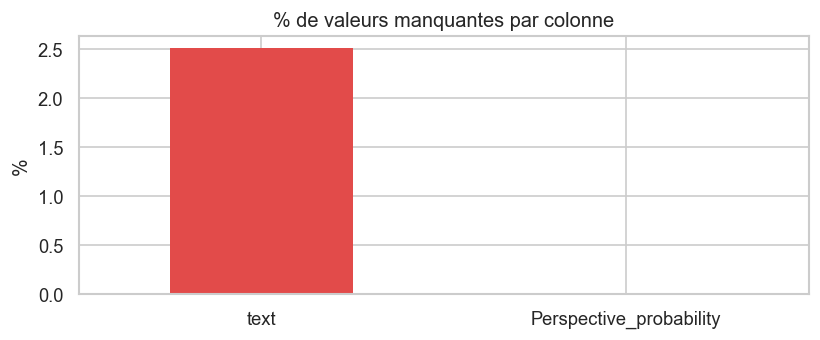

In [26]:
# =============================================================================
# CELLULE 6 — Valeurs manquantes & anomalies de label
# =============================================================================

print("=== Valeurs manquantes ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Distribution des labels ===")
print(df['Perspective_label'].value_counts().sort_index())

# Détection de labels aberrants (valeurs hors {0, 1})
labels_valides = {0, 1}
aberrants = df[~df['Perspective_label'].isin(labels_valides)]
print(f"\n=== Lignes avec label aberrant ===")
display(aberrants)

# Visualisation des manquants
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='#E24B4A', edgecolor='none')
ax.set_title('% de valeurs manquantes par colonne')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# =============================================================================
# CELLULE 7 — Analyse des doublons & messages de bots
# =============================================================================

# Doublons
n_dupl = df.duplicated(subset='text').sum()
print(f"Doublons (texte exact) : {n_dupl}")

print("\nTop 5 textes les plus répétés :")
display(df['text'].value_counts().head(5).reset_index().rename(
    columns={'text': 'texte', 'count': 'occurrences'}))

# Bots
BOT_PATTERN = r'(I am a bot|AutoModérateur|AutoModerator|performed automatically|bot)'
df['is_bot'] = df['text'].fillna('').astype(str).str.contains(BOT_PATTERN, case=False, regex=True)
print(f"\nMessages de bots détectés : {df['is_bot'].sum()}")
display(df[df['is_bot']][['text']].head(3))

Doublons (texte exact) : 742

Top 5 textes les plus répétés :


,texte,occurrences
0,Tu ne trouves pas la réponse à ta question ici ? Tu la trouveras peut-être sur r/askfrance\n\nNot finding the answer...,55
1,AutoModérateur est profondément désolé de t'informer que ton compte est trop jeune ou que tu n'as pas assez de karma...,18
2,"Bonjour,_x000D_\n_x000D_\nCette soumission a été retirée car il s'agit d'un doublon._x000D_\n_x000D_\n_x000D_\n_x000...",13
3,AutoModérateur est profondément désolé de t'informer que ton compte est trop jeune ou que tu n'as pas assez de karma...,12
4,"La publication de commentaires dans les sujets étiquetés ""Fait divers"" et ""Politique"" est réservée aux utilisateurs ...",10


C:\Users\pc\AppData\Local\Temp\ipykernel_10508\2624994970.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_bot'] = df['text'].fillna('').astype(str).str.contains(BOT_PATTERN, case=False, regex=True)



Messages de bots détectés : 212


,text
326,Hélène et le sang - Béruriers noirs \n\nPavillon 36 - Béruriers noirs\n\nLobotomie - Béruriers noirs\n\nVietnam Laos...
338,"La publication de commentaires dans les sujets étiquetés ""Fait divers"" et ""Politique"" est réservée aux utilisateurs ..."
538,"Ce post a été supprimé. Merci de ne pas mettre le lien en self.post, mais de cliquer sur le bouton ""partager un lien..."


C:\Users\pc\AppData\Local\Temp\ipykernel_10508\3434358623.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='Perspective_label', y='text_len',


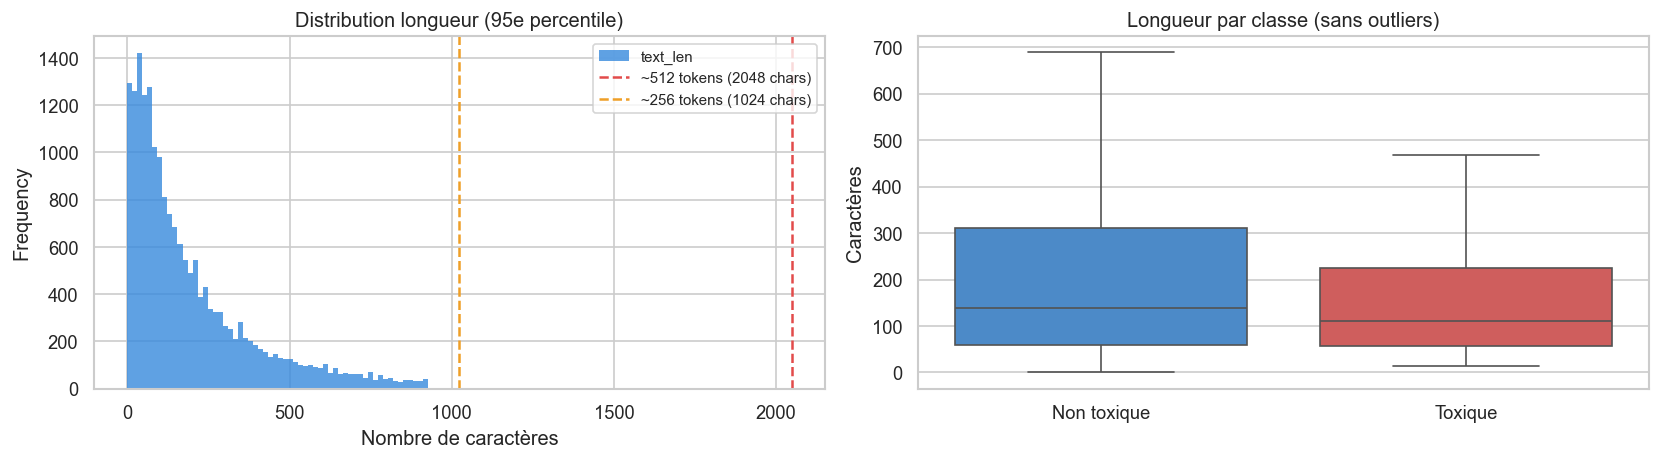

Textes > 512 tokens (~2048 chars) : 251
Textes < 10 chars                 : 895


In [28]:
# =============================================================================
# CELLULE 8 — Distribution des longueurs & seuil CamemBERT
# =============================================================================

df['text_len'] = df['text'].fillna('').str.len()
df['word_count'] = df['text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme longueur en chars (zoom sur les 95%)
p95 = df['text_len'].quantile(0.95)
df[df['text_len'] <= p95]['text_len'].plot(
    kind='hist', bins=60, ax=axes[0],
    color='#378ADD', edgecolor='none', alpha=0.8)
axes[0].axvline(2048, color='#E24B4A', lw=1.5, ls='--',
               label='~512 tokens (2048 chars)')
axes[0].axvline(1024, color='#EF9F27', lw=1.5, ls='--',
               label='~256 tokens (1024 chars)')
axes[0].set_title('Distribution longueur (95e percentile)')
axes[0].set_xlabel('Nombre de caractères')
axes[0].legend(fontsize=9)

# Boxplot par label
valid = df[df['Perspective_label'].isin([0, 1])].copy()
valid['Perspective_label'] = valid['Perspective_label'].map({0: 'Non toxique', 1: 'Toxique'})
sns.boxplot(data=valid, x='Perspective_label', y='text_len',
            palette={'Non toxique': '#378ADD', 'Toxique': '#E24B4A'},
            ax=axes[1], showfliers=False)
axes[1].set_title('Longueur par classe (sans outliers)')
axes[1].set_ylabel('Caractères')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Textes > 512 tokens (~2048 chars) : {(df['text_len'] > 2048).sum()}")
print(f"Textes < 10 chars                 : {(df['text_len'] < 10).sum()}")

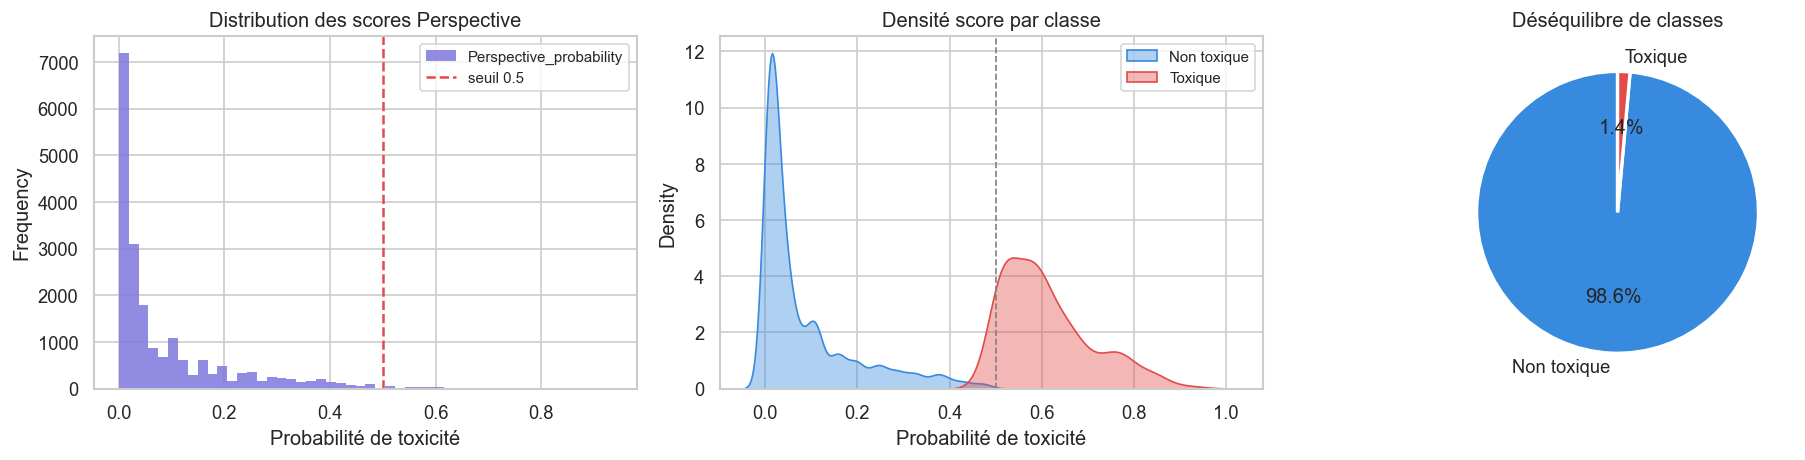

In [29]:
# =============================================================================
# CELLULE 9 — Scores Perspective & déséquilibre de classes
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribution globale des probabilités
df['Perspective_probability'].dropna().plot(
    kind='hist', bins=50, ax=axes[0],
    color='#7F77DD', edgecolor='none', alpha=0.85)
axes[0].axvline(0.5, color='#E24B4A', lw=1.5, ls='--', label='seuil 0.5')
axes[0].set_title('Distribution des scores Perspective')
axes[0].set_xlabel('Probabilité de toxicité')
axes[0].legend(fontsize=9)

# 2. KDE par classe
valid = df[df['Perspective_label'].isin([0, 1])].copy()
for label, color, name in [(0, '#378ADD', 'Non toxique'), (1, '#E24B4A', 'Toxique')]:
    subset = valid[valid['Perspective_label'] == label]['Perspective_probability'].dropna()
    sns.kdeplot(subset, ax=axes[1], fill=True, alpha=0.4,
                color=color, label=name)
axes[1].axvline(0.5, color='gray', lw=1, ls='--')
axes[1].set_title('Densité score par classe')
axes[1].set_xlabel('Probabilité de toxicité')
axes[1].legend(fontsize=9)

# 3. Pie chart déséquilibre
counts = valid['Perspective_label'].value_counts()
axes[2].pie(counts, labels=['Non toxique', 'Toxique'],
          colors=['#378ADD', '#E24B4A'],
          autopct='%1.1f%%', startangle=90,
          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Déséquilibre de classes')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# =============================================================================
# CELLULE 10 — Nettoyage complet (preprocessing pour CamemBERT)
# =============================================================================

print(f"Shape initiale : {df.shape}")

# Étape 1 : supprimer les labels aberrants et NaN texte
df_clean = df[df['Perspective_label'].isin([0, 1])].copy()
df_clean = df_clean.dropna(subset=['text'])
print(f"Après suppression NaN + labels aberrants : {df_clean.shape}")

# Étape 2 : supprimer les doublons (avant le split pour éviter le leakage)
df_clean = df_clean.drop_duplicates(subset='text', keep='first')
print(f"Après déduplications           : {df_clean.shape}")

# Étape 3 : supprimer les messages de bots
BOT_PATTERN = r'(I am a bot|AutoModérateur|AutoModerator|performed automatically)'
df_clean = df_clean[~df_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]
print(f"Après suppression bots         : {df_clean.shape}")

# Étape 4 : supprimer les textes trop courts
df_clean = df_clean[df_clean['text'].str.len() >= 3]
print(f"Après filtre texte < 3 chars  : {df_clean.shape}")

# Étape 5 : fonction de nettoyage textuel
def clean_reddit_text(text: str) -> str:
    text = text.replace('_x000D_', '')           # artefact Excel
    text = re.sub(r'&gt;', '>', text)           # entités HTML
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'http\S+', '[URL]', text)   # remplace les liens
    text = re.sub(r'\n{3,}', '\n\n', text)       # normalise sauts de ligne
    text = text.strip()
    return text

df_clean['text_clean'] = df_clean['text'].apply(clean_reddit_text)

print(f"\n✅ Dataset propre : {df_clean.shape}")
print(f"   Toxique    : {(df_clean['Perspective_label']==1).sum()}")
print(f"   Non toxique: {(df_clean['Perspective_label']==0).sum()}")

Shape initiale : (20000, 6)
Après suppression NaN + labels aberrants : (19498, 6)
Après déduplications           : (19257, 6)
Après suppression bots         : (19246, 6)


C:\Users\pc\AppData\Local\Temp\ipykernel_10508\3448171587.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean = df_clean[~df_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]


Après filtre texte < 3 chars  : (19213, 6)

✅ Dataset propre : (19213, 7)
   Toxique    : 284
   Non toxique: 18929


In [31]:
df_clean.head()

,text,Perspective_probability,Perspective_label,is_bot,text_len,word_count,text_clean
0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",0.041915,0,False,120.0,23.0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r..."
1,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",0.008671,0,False,108.0,21.0,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post."
2,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",0.110887,0,False,161.0,28.0,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ..."
3,Non pas de problème de ce côté là heureusement !,0.004021,0,False,48.0,10.0,Non pas de problème de ce côté là heureusement !
4,"&gt;Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais t...",0.254629,0,False,507.0,81.0,">Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais tran..."


Token indices sequence length is longer than the specified maximum sequence length for this model (576 > 512). Running this sequence through the model will result in indexing errors


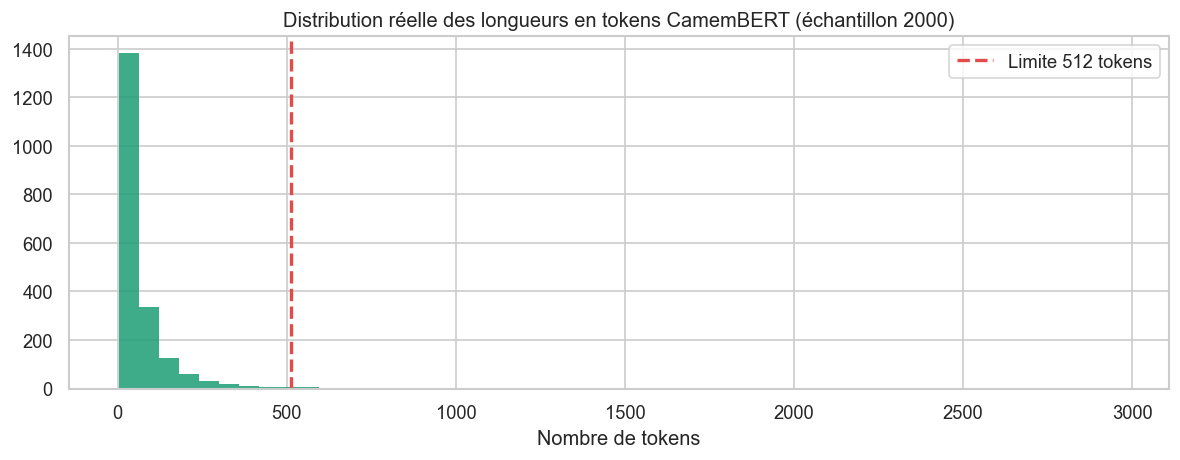

Textes > 512 tokens (échantillon) : 30 / 2000 (1.5%)
Max tokens observé : 2960
Médiane            : 36


In [32]:
# =============================================================================
# CELLULE 12 — Tokenisation CamemBERT & analyse des longueurs réelles
# =============================================================================


from transformers import CamembertTokenizer

tokenizer = CamembertTokenizer.from_pretrained('camembert-base')

# Calcul des longueurs réelles en tokens sur le dataset propre
sample = df_clean['text_clean'].sample(2000, random_state=42)
token_lens = [len(tokenizer.encode(t, add_special_tokens=True)) for t in sample]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lens, bins=50, color='#1D9E75', edgecolor='none', alpha=0.85)
ax.axvline(512, color='#E24B4A', lw=2, ls='--', label='Limite 512 tokens')
ax.set_title('Distribution réelle des longueurs en tokens CamemBERT (échantillon 2000)')
ax.set_xlabel('Nombre de tokens')
ax.legend()
plt.tight_layout()
plt.savefig('token_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

over_512 = sum(1 for l in token_lens if l > 512)
print(f"Textes > 512 tokens (échantillon) : {over_512} / {len(token_lens)} "
      f"({over_512/len(token_lens)*100:.1f}%)")
print(f"Max tokens observé : {max(token_lens)}")
print(f"Médiane            : {int(np.median(token_lens))}")

In [33]:
# =============================================================================
# CELLULE 13 — Installation & imports
# =============================================================================

from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import CamembertTokenizer, CamembertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                               recall_score, f1_score,
                               classification_report, confusion_matrix)
from tqdm.notebook import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device : cuda
PyTorch : 2.6.0+cu126


In [34]:
# =============================================================================
# CELLULE 14 — Dataset PyTorch & hyperparamètres
# =============================================================================

MODEL_NAME = 'camembert-base'
MAX_LEN    = 128   # médiane = 36 tokens → 128 suffit largement, 3x plus rapide que 512
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5
N_FOLDS    = 5

tokenizer = CamembertTokenizer.from_pretrained(MODEL_NAME)

class ToxicDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

# Données issues du preprocessing (cellule 10)
texts_all  = df_clean['text_clean'].tolist()
labels_all = df_clean['Perspective_label'].tolist()
print(f"Total : {len(texts_all)} textes | toxique : {sum(labels_all)}")

# Poids pour compenser le déséquilibre (69:1)
n_neg = labels_all.count(0)
n_pos = labels_all.count(1)
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(DEVICE)
print(f"pos_weight : {pos_weight.item():.1f}")

Total : 19213 textes | toxique : 284
pos_weight : 66.7


In [35]:
# =============================================================================
# CELLULE 15 — Fonctions d'entraînement et d'évaluation
# =============================================================================

def train_epoch(model, loader, optimizer, scheduler, loss_fn):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        lbls      = batch['labels'].to(DEVICE)

        logits = model(input_ids=input_ids,
                       attention_mask=attn_mask).logits   # (B, 2)

        # BCEWithLogitsLoss sur la classe positive uniquement
        loss = loss_fn(logits[:, 1], lbls.float())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            logits = model(input_ids=input_ids,
                           attention_mask=attn_mask).logits
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred,    zero_division=0),
        'f1':        f1_score(y_true, y_pred,         zero_division=0),
        'y_true': y_true,
        'y_pred': y_pred
    }

In [36]:
# =============================================================================
# CELLULE 16 — Pipeline d'entraînement (anti-overfitting + Focal Loss)
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CamembertTokenizerFast, CamembertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import numpy as np

# ── Device ───────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# ── Hyperparamètres ───────────────────────────────────────────────────────
MODEL_NAME   = 'camembert-base'
MAX_LEN      = 128
BATCH_SIZE   = 16 if DEVICE.type == 'cuda' else 8
EPOCHS       = 15           # early stopping choisira le meilleur point
LR_BASE      = 5e-6         # LR faible pour le corps CamemBERT (limite l'overfitting)
LR_HEAD      = 3e-5         # LR plus eleve pour la tete de classification
WEIGHT_DECAY = 0.1          # regularisation L2 plus forte (0.01 insuffisant)
WARMUP_RATIO = 0.1
GRAD_CLIP    = 1.0
PATIENCE     = 3            # early stopping patience
N_FROZEN     = 6            # geler les 6 premieres couches sur 12 (anti-overfitting)
FOCAL_GAMMA  = 2.0          # Focal Loss : penalise davantage les exemples difficiles

print(f'BATCH_SIZE={BATCH_SIZE} | EPOCHS={EPOCHS} | PATIENCE={PATIENCE}')
print(f'LR_BASE={LR_BASE} | LR_HEAD={LR_HEAD} | WEIGHT_DECAY={WEIGHT_DECAY}')
print(f'N_FROZEN={N_FROZEN}/12 couches | FOCAL_GAMMA={FOCAL_GAMMA}')

# ── Focal Loss (meilleure que BCE pour imbalance severe) ─────────────────
# Contrairement a BCEWithLogitsLoss(logits[:,1], ...) qui ignorait le logit negatif,
# la Focal Loss utilise les deux logits via cross-entropy → correction du bug.
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights  # tensor [w0, w1]

    def forward(self, logits, targets):
        # logits: (B, 2)  targets: (B,) long
        ce = F.cross_entropy(logits, targets,
                             weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce)                    # proba de la bonne classe
        return ((1 - pt) ** self.gamma * ce).mean()

# ── Tokenizer ────────────────────────────────────────────────────────────
print('\nChargement du tokenizer...')
tokenizer = CamembertTokenizerFast.from_pretrained(MODEL_NAME)

# ── Dataset ──────────────────────────────────────────────────────────────
class ToxicDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts, padding=True, truncation=True, max_length=MAX_LEN
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Split 80 / 10 / 10 ───────────────────────────────────────────────────
texts  = df_clean['text_clean'].tolist()
labels = df_clean['Perspective_label'].tolist()

X_tmp, X_test, y_tmp, y_test = train_test_split(
    texts, labels, test_size=0.10, stratify=labels, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1111, stratify=y_tmp, random_state=42
)
print(f'\nTrain : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

print('Tokenisation...')
train_ds = ToxicDataset(X_train, y_train)
val_ds   = ToxicDataset(X_val,   y_val)
test_ds  = ToxicDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Modele ───────────────────────────────────────────────────────────────
print('\nChargement CamemBERT...')
model = CamembertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# ── Gel des N_FROZEN premieres couches (anti-overfitting) ─────────────────
# CamemBERT = 12 couches transformer. On gele les plus bas (features generales),
# on laisse les hautes s'adapter au domaine (toxicite Reddit).
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False
for layer in model.roberta.encoder.layer[:N_FROZEN]:
    for param in layer.parameters():
        param.requires_grad = False

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'Params entrainables : {n_train:,} / {n_total:,} ({n_train/n_total*100:.1f}%)')

# ── Poids de classe pour Focal Loss ─────────────────────────────────────
n_neg = y_train.count(0)
n_pos = y_train.count(1)
ratio = n_neg / n_pos
# poids inverses a la frequence : classe 0 poids 1, classe 1 poids ratio
class_weights = torch.tensor([1.0, ratio], dtype=torch.float).to(DEVICE)
print(f'Desequilibre : {n_neg} vs {n_pos} → class_weights=[1.0, {ratio:.1f}]')

loss_fn = FocalLoss(gamma=FOCAL_GAMMA, class_weights=class_weights)

# ── Optimiseur avec LR differentiel ──────────────────────────────────────
# Corps BERT : LR tres faible pour ne pas detruire les representations pre-entrainées
# Tete classifier : LR plus eleve, elle part de zero
no_decay = ['bias', 'LayerNorm.weight']
optimizer_params = [
    # Corps CamemBERT - LR faible
    {'params': [p for n, p in model.roberta.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)],
     'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.roberta.named_parameters()
                if p.requires_grad and     any(nd in n for nd in no_decay)],
     'lr': LR_BASE, 'weight_decay': 0.0},
    # Tete de classification - LR plus eleve
    {'params': [p for n, p in model.classifier.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'lr': LR_HEAD, 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.classifier.named_parameters()
                if     any(nd in n for nd in no_decay)],
     'lr': LR_HEAD, 'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(optimizer_params)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
print(f'Steps total={total_steps} | Warmup={warmup_steps}')

# ── Fonction train/eval ───────────────────────────────────────────────────
def run_epoch(loader, training=True):
    model.train(training)
    total_loss, all_preds, all_lbls = 0.0, [], []

    with torch.set_grad_enabled(training):
        loop = tqdm(loader, desc='Train' if training else 'Eval', leave=False)
        for batch in loop:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask  = batch['attention_mask'].to(DEVICE)
            lbl        = batch['labels'].to(DEVICE)

            logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
            loss   = loss_fn(logits, lbl)  # Focal Loss sur les 2 logits

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_lbls.extend(lbl.cpu().numpy())
            loop.set_postfix(loss=f'{loss.item():.3f}')

    y_true = np.array(all_lbls)
    y_pred = np.array(all_preds)
    return {
        'loss':      total_loss / len(loader),
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'y_true': y_true, 'y_pred': y_pred
    }

# ── Boucle avec early stopping sur Val F1 ─────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_recall': []}
best_val_f1      = 0.0
patience_counter = 0
best_state       = None

print(f'\nEntrainement (max {EPOCHS} epochs, early stopping patience={PATIENCE})')
print('=' * 65)

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch + 1}/{EPOCHS}')
    train_m = run_epoch(train_loader, training=True)
    val_m   = run_epoch(val_loader,   training=False)

    history['train_loss'].append(train_m['loss'])
    history['val_loss'].append(val_m['loss'])
    history['val_f1'].append(val_m['f1'])
    history['val_recall'].append(val_m['recall'])

    gap = train_m['f1'] - val_m['f1']
    print(f'  Train : loss={train_m["loss"]:.4f} | acc={train_m["accuracy"]:.3f} | f1={train_m["f1"]:.3f}')
    print(f'  Val   : loss={val_m["loss"]:.4f}   | acc={val_m["accuracy"]:.3f} | f1={val_m["f1"]:.3f} | recall={val_m["recall"]:.3f}  [gap={gap:+.3f}]')

    if val_m['f1'] > best_val_f1:
        best_val_f1 = val_m['f1']
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f'  Meilleur F1 val : {best_val_f1:.4f} - sauvegarde')
    else:
        patience_counter += 1
        print(f'  Pas d amelioration ({patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {epoch + 1}')
            break

model.load_state_dict(best_state)
print(f'\nMeilleur F1 validation : {best_val_f1:.4f}')


Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
BATCH_SIZE=16 | EPOCHS=15 | PATIENCE=3
LR_BASE=5e-06 | LR_HEAD=3e-05 | WEIGHT_DECAY=0.1
N_FROZEN=6/12 couches | FOCAL_GAMMA=2.0

Chargement du tokenizer...

Train : 15369 | Val : 1922 | Test : 1922
Tokenisation...

Chargement CamemBERT...


Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Params entrainables : 43,119,362 / 110,623,490 (39.0%)
Desequilibre : 15141 vs 228 → class_weights=[1.0, 66.4]
Steps total=14415 | Warmup=1441

Entrainement (max 15 epochs, early stopping patience=3)

Epoch 1/15


  Train : loss=1.2550 | acc=0.945 | f1=0.016
  Val   : loss=1.3289   | acc=0.985 | f1=0.000 | recall=0.000  [gap=+0.016]
  Pas d amelioration (1/3)

Epoch 2/15


  Train : loss=1.2391 | acc=0.986 | f1=0.264
  Val   : loss=0.7845   | acc=0.984 | f1=0.475 | recall=0.500  [gap=-0.211]
  Meilleur F1 val : 0.4746 - sauvegarde

Epoch 3/15


...

  Train : loss=0.1855 | acc=0.998 | f1=0.920
  Val   : loss=1.0984   | acc=0.988 | f1=0.610 | recall=0.643  [gap=+0.310]
  Pas d amelioration (1/3)

Epoch 12/15


  Train : loss=0.1333 | acc=0.998 | f1=0.932
  Val   : loss=1.5925   | acc=0.990 | f1=0.583 | recall=0.500  [gap=+0.349]
  Pas d amelioration (2/3)

Epoch 13/15


  Train : loss=0.0913 | acc=0.999 | f1=0.950
  Val   : loss=1.4480   | acc=0.990 | f1=0.630 | recall=0.607  [gap=+0.320]
  Meilleur F1 val : 0.6296 - sauvegarde

Epoch 14/15


  Train : loss=0.0814 | acc=0.998 | f1=0.941
  Val   : loss=1.5743   | acc=0.990 | f1=0.630 | recall=0.607  [gap=+0.312]
  Pas d amelioration (1/3)

Epoch 15/15


  Train : loss=0.0656 | acc=0.999 | f1=0.967
  Val   : loss=1.7611   | acc=0.990 | f1=0.583 | recall=0.500  [gap=+0.384]
  Pas d amelioration (2/3)

Meilleur F1 validation : 0.6296


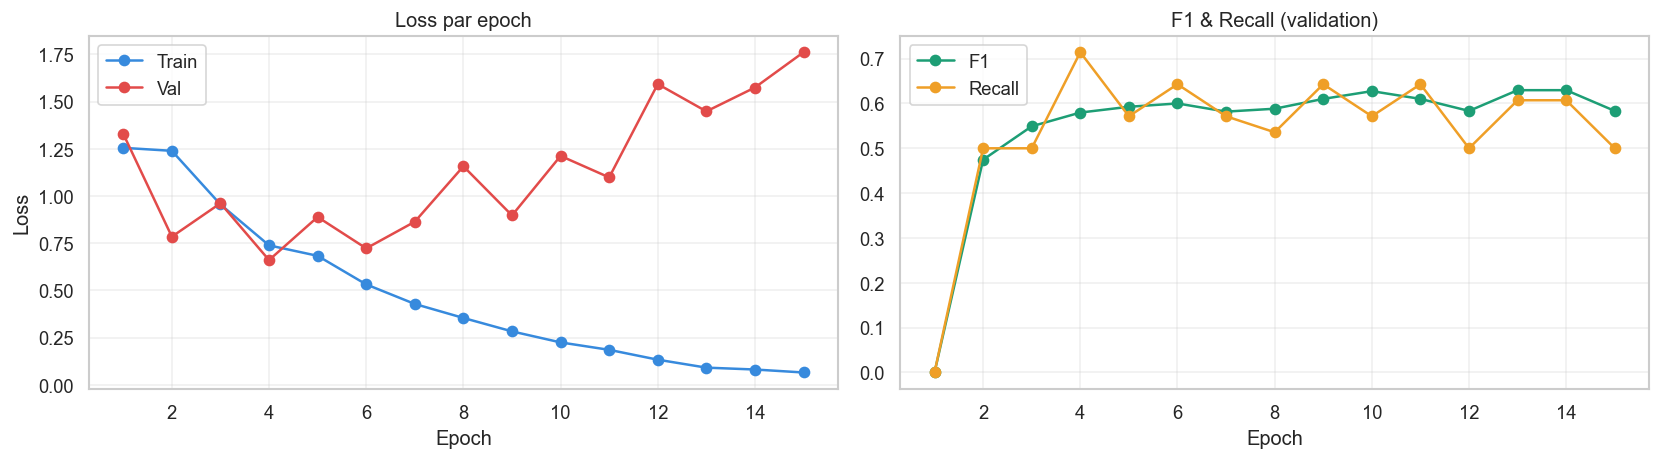

EVALUATION FINALE SUR LE TEST SET (données jamais vues)



Accuracy  : 0.9870
Precision : 0.5789
Recall    : 0.3929
F1-score  : 0.4681

--- Rapport de classification détaillé ---
              precision    recall  f1-score   support

 Non toxique       0.99      1.00      0.99      1894
     Toxique       0.58      0.39      0.47        28

    accuracy                           0.99      1922
   macro avg       0.79      0.69      0.73      1922
weighted avg       0.99      0.99      0.99      1922



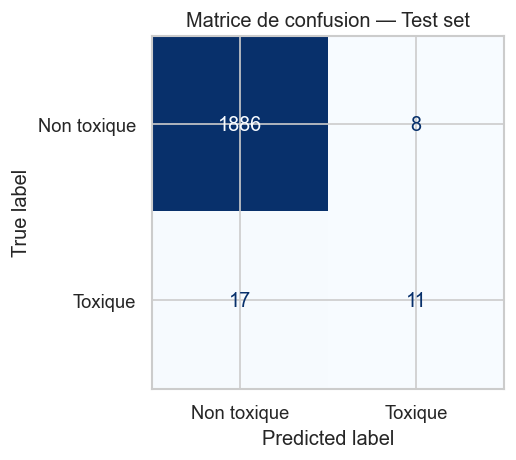

In [37]:
# =============================================================================
# CELLULE 17 — Visualisation & évaluation finale sur le test set
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Courbes d'apprentissage ────────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history['train_loss'], 'o-', color='#378ADD', label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   'o-', color='#E24B4A', label='Val')
axes[0].set_title('Loss par epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['val_f1'],     'o-', color='#1D9E75', label='F1')
axes[1].plot(epochs_ran, history['val_recall'], 'o-', color='#EF9F27', label='Recall')
axes[1].set_title('F1 & Recall (validation)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Evaluation finale sur le TEST set ─────────────────────────────────────
print('=' * 60)
print('EVALUATION FINALE SUR LE TEST SET (données jamais vues)')
print('=' * 60)

test_m = run_epoch(test_loader, training=False)

print(f'\nAccuracy  : {test_m["accuracy"]:.4f}')
print(f'Precision : {test_m["precision"]:.4f}')
print(f'Recall    : {test_m["recall"]:.4f}')
print(f'F1-score  : {test_m["f1"]:.4f}')

print('\n--- Rapport de classification détaillé ---')
print(classification_report(test_m['y_true'], test_m['y_pred'],
                             target_names=['Non toxique', 'Toxique']))

# ── Matrice de confusion ──────────────────────────────────────────────────
cm = confusion_matrix(test_m['y_true'], test_m['y_pred'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Non toxique', 'Toxique']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — Test set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Modèle sauvegardé dans "camembert_toxic_model/"
EXEMPLES D INFERENCE
[Non toxique  0.34%] Ce commentaire est vraiment utile, merci pour le partage !
[TOXIQUE      100.00%] Va te faire foutre espece d idiot, t es nul a chier !
[Non toxique  0.54%] Je ne suis pas d accord avec ton point de vue, mais je respecte t
[TOXIQUE      100.00%] Tu es une merde et tout le monde te deteste.
[Non toxique  0.33%] Super article, tres bien explique, bravo !
[TOXIQUE      79.98%] Ferme ta gueule, personne ne t a demande ton avis.

--- Sensibilité au seuil de décision (val set) ---
 threshold       f1   recall  precision
      0.10 0.615385 0.714286   0.540541
      0.15 0.625000 0.714286   0.555556
      0.20 0.625000 0.714286   0.555556
      0.25 0.622951 0.678571   0.575758
      0.30 0.633333 0.678571   0.593750
      0.35 0.610169 0.642857   0.580645
      0.40 0.631579 0.642857   0.620690
      0.45 0.642857 0.642857   0.642857
      0.50 0.629630 0.607143   0.653846
      0.55 0.629630 0.607143  

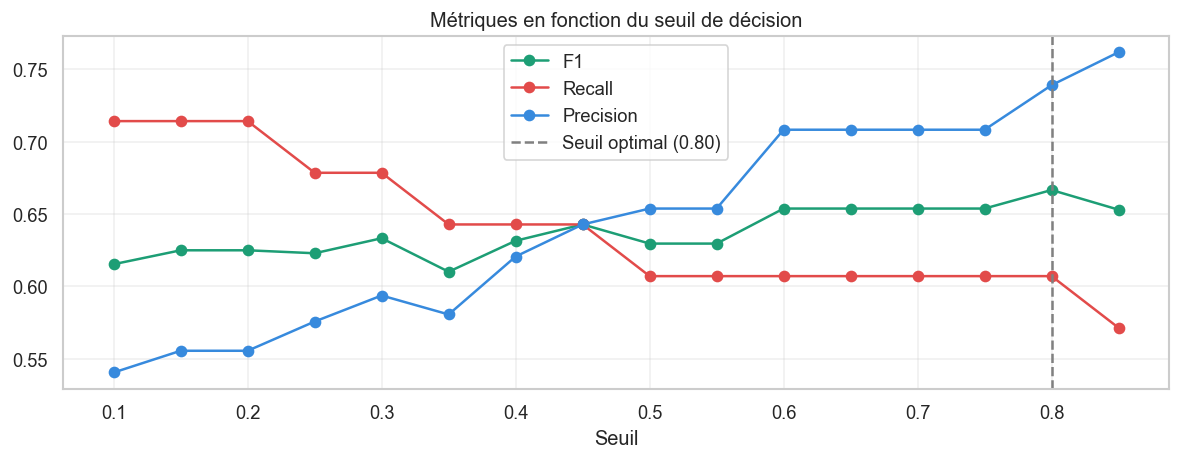

In [38]:
# =============================================================================
# CELLULE 18 — Sauvegarde du modèle & inférence
# =============================================================================

import os

# ── Sauvegarde ────────────────────────────────────────────────────────────
SAVE_DIR = 'camembert_toxic_model'
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Modèle sauvegardé dans "{SAVE_DIR}/"')

# ── Fonction d'inférence ─────────────────────────────────────────────────
def predict_toxicity(texts, threshold=0.5):
    model.eval()
    enc = tokenizer(texts, padding=True, truncation=True,
                    max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = model(**enc).logits
    proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    labels = (proba >= threshold).astype(int)
    return labels, proba

# ── Exemples d'inférence ──────────────────────────────────────────────────
exemples = [
    'Ce commentaire est vraiment utile, merci pour le partage !',
    'Va te faire foutre espece d idiot, t es nul a chier !',
    'Je ne suis pas d accord avec ton point de vue, mais je respecte ton opinion.',
    'Tu es une merde et tout le monde te deteste.',
    'Super article, tres bien explique, bravo !',
    'Ferme ta gueule, personne ne t a demande ton avis.',
]

print('=' * 70)
print('EXEMPLES D INFERENCE')
print('=' * 70)

labels_pred, probas = predict_toxicity(exemples)
for text, lbl, prob in zip(exemples, labels_pred, probas):
    tag = 'TOXIQUE     ' if lbl == 1 else 'Non toxique '
    print(f'[{tag} {prob:.2%}] {text[:65]}')

# ── Analyse de sensibilité au seuil (sur val set) ────────────────────────
print('\n--- Sensibilité au seuil de décision (val set) ---')
model.eval()
val_probas, val_true = [], []
with torch.no_grad():
    for batch in val_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = model(input_ids=ids, attention_mask=mask).logits
        val_probas.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        val_true.extend(batch['labels'].numpy())

import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score

val_probas = np.array(val_probas)
y_true_val = np.array(val_true)

thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for thr in thresholds:
    preds = (val_probas >= thr).astype(int)
    rows.append({
        'threshold': round(float(thr), 2),
        'f1':        f1_score(y_true_val, preds, zero_division=0),
        'recall':    recall_score(y_true_val, preds, zero_division=0),
        'precision': precision_score(y_true_val, preds, zero_division=0)
    })

df_thr = pd.DataFrame(rows)
best_row = df_thr.loc[df_thr['f1'].idxmax()]
print(df_thr.to_string(index=False))
print(f'\nMeilleur seuil : {best_row["threshold"]:.2f}'
      f' → F1={best_row["f1"]:.4f}, Recall={best_row["recall"]:.4f}')

# Visualisation
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_thr['threshold'], df_thr['f1'],        'o-', label='F1',        color='#1D9E75')
ax.plot(df_thr['threshold'], df_thr['recall'],    'o-', label='Recall',    color='#E24B4A')
ax.plot(df_thr['threshold'], df_thr['precision'], 'o-', label='Precision', color='#378ADD')
ax.axvline(best_row['threshold'], color='gray', ls='--', lw=1.5,
           label=f'Seuil optimal ({best_row["threshold"]:.2f})')
ax.set_title('Métriques en fonction du seuil de décision')
ax.set_xlabel('Seuil')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
